# Import Libraries

In [ ]:
import math
import itertools
from typing import List, Dict, Tuple, Any, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style="whitegrid")

# Load Dataset and Split Seasons

In [ ]:
dataset2_path = "/content/drive/MyDrive/BAT RAT DATASET/dataset1_with_rat_duration.csv"
df2 = pd.read_csv(dataset2_path)

# Display columns and shape
print("Columns in dataset2:", df2.columns)
print("Dataset2 shape:", df2.shape)

# Split by month or season
if 'month' in df2.columns:
    df2_winter = df2[df2['month'].isin([0, 1, 2])]
    df2_spring = df2[df2['month'].isin([3, 4, 5, 6])]
elif 'season' in df2.columns:
    df2_winter = df2[df2['season'].str.lower() == 'winter']
    df2_spring = df2[df2['season'].str.lower() == 'spring']
else:
    raise ValueError("Dataset2 must contain either a 'month' or 'season' column for splitting.")

# Save seasonal CSVs
winter_csv_path = "/content/drive/MyDrive/BAT RAT DATASET/winter_dataset1_with_rat_duration.csv"
spring_csv_path = "/content/drive/MyDrive/BAT RAT DATASET/spring_dataset1_with_rat_duration.csv"
df2_winter.to_csv(winter_csv_path, index=False)
df2_spring.to_csv(spring_csv_path, index=False)

print("Winter dataset2 shape:", df2_winter.shape)
print("Spring dataset2 shape:", df2_spring.shape)

Columns in dataset2: Index(['start_time', 'bat_landing_to_food', 'habit', 'rat_period_start',
       'rat_period_end', 'seconds_after_rat_arrival', 'risk', 'reward',
       'month', 'sunset_time', 'hours_after_sunset', 'season',
       'rat_presence_duration_sec'],
      dtype='object')
Dataset2 shape: (907, 13)
Winter dataset2 shape: (151, 13)
Spring dataset2 shape: (756, 13)


#Define Candidate Predictors and Response

In [ ]:
response_var = "bat_landing_to_food"
candidate_predictors = [
    "seconds_after_rat_arrival",
    "risk",
    "reward",
    'rat_presence_duration_sec'
]

print("Response variable:", response_var)
print("Candidate predictors:", candidate_predictors)

Response variable: bat_landing_to_food
Candidate predictors: ['seconds_after_rat_arrival', 'risk', 'reward', 'rat_presence_duration_sec']


#Define Utility Functions for Model Selection

In [ ]:
# Model selection functions (subset selection by test R²)

def _fit_and_score(X_train, X_test, y_train, y_test, predictors):
    lm = LinearRegression()
    lm.fit(X_train[predictors], y_train)

    yhat_test = lm.predict(X_test[predictors])
    yhat_train = lm.predict(X_train[predictors])

    r2_test = r2_score(y_test, yhat_test)
    r2_train = r2_score(y_train, yhat_train)
    mse_test = mean_squared_error(y_test, yhat_test)
    mae_test = mean_absolute_error(y_test, yhat_test)
    rmse_test = math.sqrt(mse_test)

    # statsmodels for adjusted R² on train
    Xsm = sm.add_constant(X_train[predictors], has_constant="add")
    sm_model = sm.OLS(y_train, Xsm).fit()
    adj_r2_train = sm_model.rsquared_adj

    return {
        "predictors": predictors[:],
        "n_features": len(predictors),
        "r2_test": r2_test,
        "r2_train": r2_train,
        "adj_r2_train": adj_r2_train,
        "mse_test": mse_test,
        "rmse_test": rmse_test,
        "mae_test": mae_test,
        "sm_summary": sm_model.summary(),
    }

def _all_subsets(features, min_k=1, max_k=None):
    if max_k is None:
        max_k = len(features)
    for r in range(min_k, max_k+1):
        for combo in itertools.combinations(features, r):
            yield list(combo)

def select_best_predictors_by_test_r2(dataset_path, response_var, candidate_predictors, test_size=0.4, random_state=42):
    df = pd.read_csv(dataset_path)
    X = df[candidate_predictors]
    y = df[response_var]
    data = pd.concat([X, y], axis=1).dropna()
    X = data[candidate_predictors]
    y = data[response_var]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    results = []
    for subset in _all_subsets(candidate_predictors):
        res = _fit_and_score(X_train, X_test, y_train, y_test, subset)
        results.append({
            "predictors": ", ".join(res["predictors"]),
            "n_features": res["n_features"],
            "r2_test": res["r2_test"],
            "r2_train": res["r2_train"],
            "adj_r2_train": res["adj_r2_train"],
            "mse_test": res["mse_test"],
            "rmse_test": res["rmse_test"],
            "mae_test": res["mae_test"],
        })

    ranking = pd.DataFrame(results).sort_values(["r2_test", "adj_r2_train"], ascending=[False, False]).reset_index(drop=True)
    best_list = [c.strip() for c in ranking.loc[0, "predictors"].split(",")] if not ranking.empty else []

    return best_list, ranking

def print_ranking_table(ranking_df, top_n=5):
    display_df = ranking_df.copy()
    if top_n:
        display_df = display_df.head(top_n)
    for col in ["r2_test", "r2_train", "adj_r2_train", "mse_test", "rmse_test", "mae_test"]:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    print("\n===== Model Subset Ranking (sorted by best test R²) =====")
    print(display_df.to_string(index=False))

#Define Linear Regression Workflow

In [ ]:
def run_linear_workflow(data, response_var, predictor_vars, test_size=0.4, random_state=42, clip_negative_preds=True, show_plots=True):
    df = pd.read_csv(data) if isinstance(data, str) else data.copy()
    X = df[predictor_vars]
    y = df[response_var]
    data_clean = pd.concat([X, y], axis=1).dropna()
    X_clean = data_clean[predictor_vars]
    y_clean = data_clean[response_var]

    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=test_size, random_state=random_state)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if clip_negative_preds:
        y_pred = np.where(y_pred < 0, 0, y_pred)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    nrmse = rmse / (y_test.max() - y_test.min())

    # Statsmodels OLS
    x_with_const = sm.add_constant(X_clean)
    ols_model = sm.OLS(y_clean, x_with_const).fit()

    # VIF
    X_with_const = sm.add_constant(X_clean)
    vif_rows = []
    for i in range(X_with_const.shape[1]):
        if X_with_const.columns[i] == "const":
            continue
        vif_rows.append({"Variable": X_with_const.columns[i], "VIF": variance_inflation_factor(X_with_const.values, i)})
    vif_df = pd.DataFrame(vif_rows)

    if show_plots:
        # Actual vs Predicted
        plt.figure(figsize=(8,6))
        plt.scatter(y_test, y_pred, alpha=0.7)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
        plt.xlabel(f"Actual {response_var}")
        plt.ylabel(f"Predicted {response_var}")
        plt.title("Actual vs Predicted")
        plt.show()

    return {
        "df": df,
        "data_clean": data_clean,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "model": model,
        "ols_model": ols_model,
        "metrics": {"r2_test": r2, "mse_test": mse, "mae_test": mae, "rmse_test": rmse, "nrmse_test": nrmse},
        "vif": vif_df
    }

#Winter Linear Regression


Running Linear Regression for WINTER dataset

===== Model Subset Ranking (sorted by best test R²) =====
                       predictors  n_features  r2_test  r2_train  adj_r2_train  mse_test  rmse_test  mae_test
        seconds_after_rat_arrival           1  -0.0132    0.0059       -0.0054  422.3544    20.5513    7.4543
seconds_after_rat_arrival, reward           2  -0.0164    0.0072       -0.0156  423.6828    20.5836    7.4929
                           reward           1  -0.0179    0.0010       -0.0104  424.3076    20.5987    7.4455
  seconds_after_rat_arrival, risk           2  -0.0258    0.0255        0.0031  427.5780    20.6780    7.4730
                             risk           1  -0.0281    0.0225        0.0114  428.5560    20.7016    7.4248


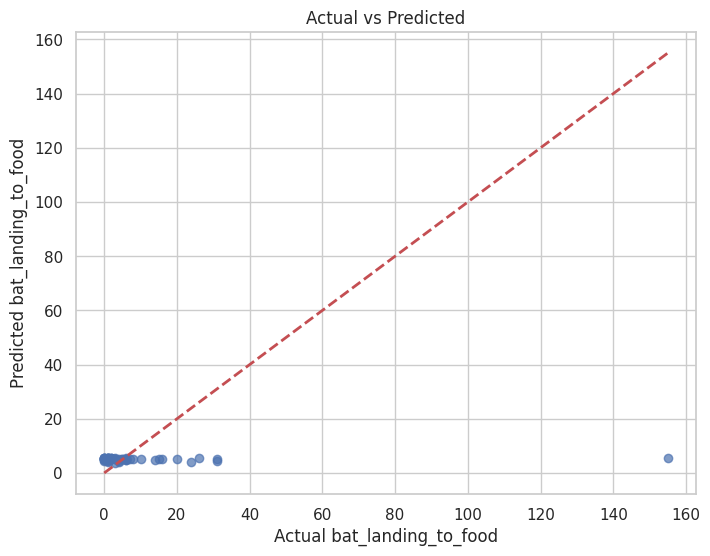

In [ ]:
print("\n============================")
print("Running Linear Regression for WINTER dataset")
print("============================")

# Pick best predictors
best_predictors_winter, ranking_winter = select_best_predictors_by_test_r2(
    winter_csv_path,
    response_var,
    candidate_predictors,
    test_size=0.4,
    random_state=42
)

print_ranking_table(ranking_winter, top_n=5)

# Run linear regression workflow
results_winter = run_linear_workflow(
    winter_csv_path,
    response_var,
    best_predictors_winter,
    test_size=0.4,
    random_state=42,
    clip_negative_preds=True,
    show_plots=True
)

#Spring Linear Regression


Running Linear Regression for SPRING dataset

===== Model Subset Ranking (sorted by best test R²) =====
                                                        predictors  n_features  r2_test  r2_train  adj_r2_train  mse_test  rmse_test  mae_test
                                                      risk, reward           2   0.0468    0.0618        0.0577  497.1715    22.2973   12.3730
                                                              risk           1   0.0440    0.0357        0.0335  498.6028    22.3294   12.2245
                           risk, reward, rat_presence_duration_sec           3   0.0436    0.0619        0.0557  498.8579    22.3351   12.3852
                                   risk, rat_presence_duration_sec           2   0.0427    0.0357        0.0314  499.3105    22.3453   12.2257
seconds_after_rat_arrival, risk, reward, rat_presence_duration_sec           4   0.0248    0.0641        0.0557  508.6166    22.5525   12.5925


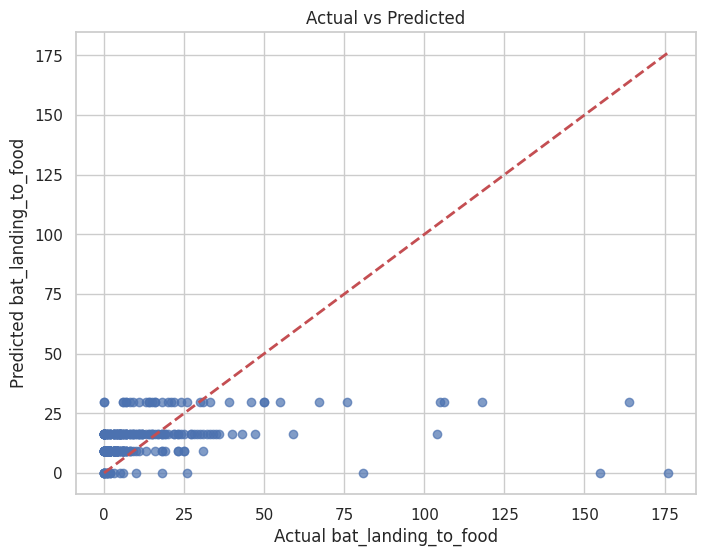

In [ ]:
print("\n============================")
print("Running Linear Regression for SPRING dataset")
print("============================")

# Pick best predictors
best_predictors_spring, ranking_spring = select_best_predictors_by_test_r2(
    spring_csv_path,
    response_var,
    candidate_predictors,
    test_size=0.4,
    random_state=42
)

print_ranking_table(ranking_spring, top_n=5)

# Run linear regression workflow
results_spring = run_linear_workflow(
    spring_csv_path,
    response_var,
    best_predictors_spring,
    test_size=0.4,
    random_state=42,
    clip_negative_preds=True,
    show_plots=True
)

#Compare Winter and Spring Linear Regression

In [ ]:
# ===============================================
# PERFORMANCE COMPARISON BETWEEN SEASONS
# ===============================================

print("\n============================")
print("Performance Comparison: Winter vs Spring")
print("============================")

winter_metrics = results_winter["metrics"]
spring_metrics = results_spring["metrics"]

comparison_df = pd.DataFrame({
    "Metric": ["R²", "MSE", "RMSE", "MAE", "NRMSE"],
    "Winter": [
        round(winter_metrics["r2_test"], 4),
        round(winter_metrics["mse_test"], 4),
        round(winter_metrics["rmse_test"], 4),
        round(winter_metrics["mae_test"], 4),
        round(winter_metrics["nrmse_test"], 4)
    ],
    "Spring": [
        round(spring_metrics["r2_test"], 4),
        round(spring_metrics["mse_test"], 4),
        round(spring_metrics["rmse_test"], 4),
        round(spring_metrics["mae_test"], 4),
        round(spring_metrics["nrmse_test"], 4)
    ]
})

print(comparison_df.to_string(index=False))


Performance Comparison: Winter vs Spring
Metric   Winter   Spring
    R²  -0.0132   0.0748
   MSE 422.3544 482.5618
  RMSE  20.5513  21.9673
   MAE   7.4543  12.0486
 NRMSE   0.1326   0.1248


#Visualization of Winter vs Spring

/tmp/ipython-input-3936495369.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


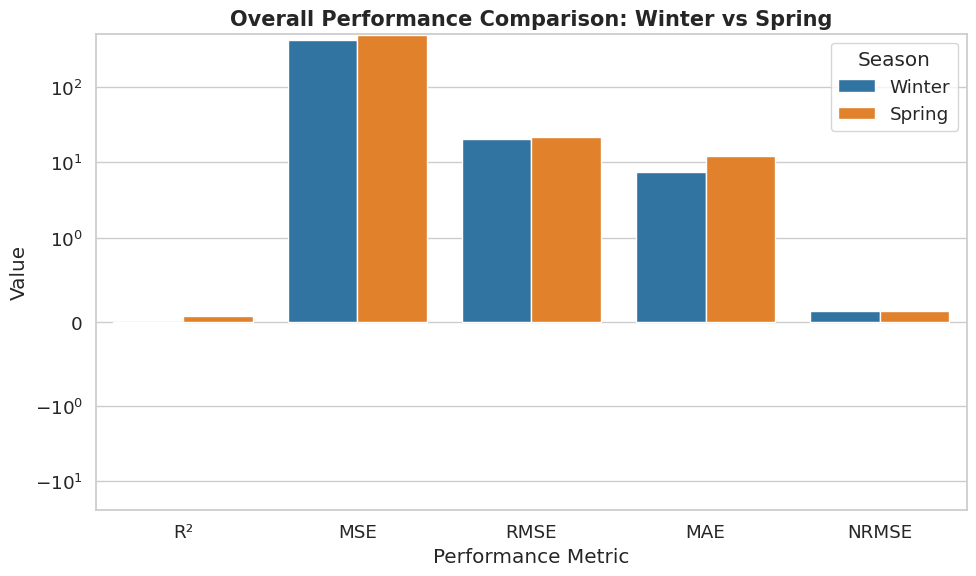

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Comparison dataframe
comparison_df = pd.DataFrame({
    "Metric": ["R²", "MSE", "RMSE", "MAE", "NRMSE"],
    "Winter": [-0.0132, 422.3544, 20.5513, 7.4543, 0.1326],
    "Spring": [0.0748, 482.5618, 21.9673, 12.0486, 0.1248]
})

# Melt for seaborn
comparison_melted = comparison_df.melt(id_vars="Metric", var_name="Season", value_name="Value")

# Set plot style
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Define colors
colors = ["#1f77b4", "#ff7f0e"]

# Plot bars with custom width and dodge
ax = sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Value",
    hue="Season",
    palette=colors,
    dodge=True,
    ci=None
)

# Custom y-axis: symlog for large metrics
ax.set_yscale("symlog", linthresh=1)

ax.set_ylabel("Value")
ax.set_xlabel("Performance Metric")
plt.title("Overall Performance Comparison: Winter vs Spring", fontsize=15, weight="bold")
plt.legend(title="Season", loc="upper right")
plt.tight_layout()
plt.show()


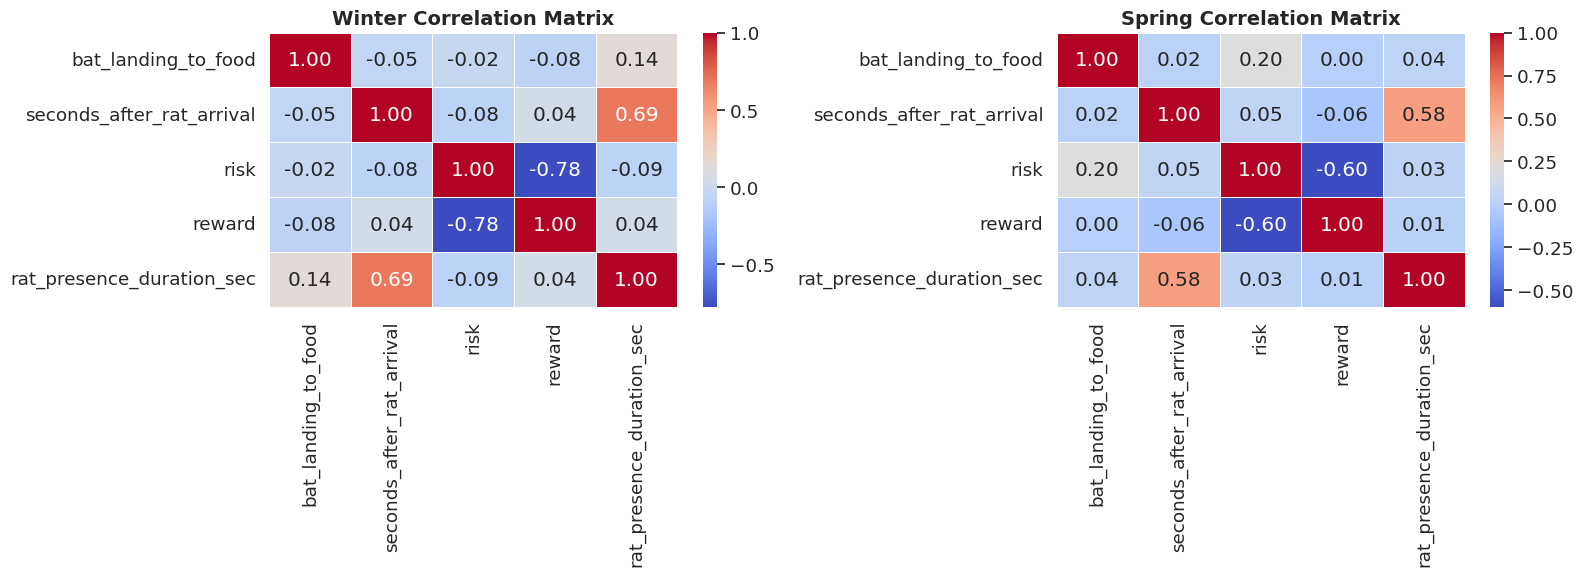

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.2)

# Columns of interest
cols_of_interest = [response_var] + candidate_predictors

# Select only numeric columns for correlation
numeric_winter = df2_winter[cols_of_interest].select_dtypes(include=["float64", "int64"])
numeric_spring = df2_spring[cols_of_interest].select_dtypes(include=["float64", "int64"])

corr_winter = numeric_winter.corr()
corr_spring = numeric_spring.corr()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # width x height

# --- Winter ---
sns.heatmap(corr_winter, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5, ax=axes[0])
axes[0].set_title("Winter Correlation Matrix", fontsize=14, fontweight="bold")

# --- Spring ---
sns.heatmap(corr_spring, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5, ax=axes[1])
axes[1].set_title("Spring Correlation Matrix", fontsize=14, fontweight="bold")

# Adjust layout for readability
plt.tight_layout()
plt.show()
